# Toy example: CP tensor decomposition

**Goal:** Explain each step of the procedure (CP model, loss, ALS, fitting) with a small **neurons × time × trials** tensor of **known rank-2 structure**, so we can *prove* the decomposition recovers the underlying dynamics when we visualize the factors.

**Outline:**
1. CP model and the loss function (what `cp_als` minimizes)
2. Build a noiseless toy tensor from two rank-1 components
3. Implement the loss in code and do **one ALS step by hand**
4. Fit with `tt.Ensemble(fit_method="cp_als")` and compare true vs recovered factors

**Presenter note:** Use this as the source for your slides (e.g. nbconvert --to slides). Each "notes" cell is for you only—mention that the example is noiseless so we can check that the method recovers the true structure.

## Imports and setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Optional: scipy.random compatibility (removed in newer SciPy; tensortools may still reference it)
try:
    import scipy.random
except (ModuleNotFoundError, AttributeError, ImportError):
    import numpy.random
    import scipy
    scipy.random = numpy.random

import tensortools as tt

np.set_printoptions(precision=3, suppress=True)

## 1. CP model and the loss function

We have a 3D tensor **X** of shape *(neurons × time × trials)*. The **CP (Canonical Polyadic)** model approximates it as a sum of *R* rank-1 tensors:

**Model:**  
$ \mathcal{X} \approx \hat{\mathcal{X}} = \sum_{r=1}^{R} \mathbf{u}_r \circ \mathbf{v}_r \circ \mathbf{w}_r $
- **u_r** (length = n_neurons): neuron loadings for component *r*  
- **v_r** (length = n_time): temporal pattern for component *r*  
- **w_r** (length = n_trials): trial loadings for component *r*  
- $ \circ $ is the outer product, so each term is a 3D array.

**Loss that cp_als minimizes (Frobenius norm squared):**  
$ \mathcal{L} = \|\mathcal{X} - \hat{\mathcal{X}}\|_F^2 = \sum_{i,j,k} (X_{ijk} - \hat{X}_{ijk})^2 $

We often report **normalized reconstruction error**:  
$ \text{err} = \|\mathcal{X} - \hat{\mathcal{X}}\|_F / \|\mathcal{X}\|_F $  
so that 0 = perfect fit and 1 = no fit.

**Presenter note:** Emphasize that cp_als minimizes the Frobenius squared error. The normalized error is what we plot in the pipeline (e.g. `tt.plot_objective`); it’s the same quantity up to normalization.

## 2. Build a toy tensor with known rank-2 structure

We choose small sizes (e.g. 8 neurons, 20 time bins, 12 trials) and **define by hand** two rank-1 components so the tensor is exactly **X = comp1 + comp2** (noiseless). Then CP with rank 2 should recover these factors (up to sign and order).

- **Component 1:** e.g. "early neurons" × "early bump in time" × "first half of trials"  
- **Component 2:** e.g. "late neurons" × "late ramp in time" × "second half of trials"

We build the tensor as the sum of two outer products: `X = u1∘v1∘w1 + u2∘v2∘w2`.

In [2]:
# Dimensions (small so we can inspect and plot easily)
n_neurons, n_time, n_trials = 8, 20, 12
R = 2  # true rank

# Time and trial indices for building interpretable patterns
t = np.linspace(0, 1, n_time)
trials = np.arange(n_trials)

# --- True factor 1: "early" neurons, early temporal bump, first half of trials ---
u1 = np.zeros(n_neurons)
u1[:4] = np.array([1.0, 0.8, 0.6, 0.4])  # first 4 neurons active
v1 = np.exp(-((t - 0.25) ** 2) / 0.05)   # bump centered early in time
w1 = np.zeros(n_trials)
w1[:6] = 1.0   # strong in first 6 trials

# --- True factor 2: "late" neurons, late ramp, second half of trials ---
u2 = np.zeros(n_neurons)
u2[4:] = np.array([0.4, 0.6, 0.8, 1.0])   # last 4 neurons active
v2 = np.maximum(0, t - 0.5)               # ramp starting mid-time
w2 = np.zeros(n_trials)
w2[6:] = 1.0   # strong in last 6 trials

# Stack into factor matrices (each column is one component)
# Shape: (n_neurons, R), (n_time, R), (n_trials, R)
U_true = np.column_stack([u1, u2])
V_true = np.column_stack([v1, v2])
W_true = np.column_stack([w1, w2])

print("U_true (neurons x rank):"); print(U_true)
print("\nV_true (time x rank) - first 5 rows:"); print(V_true[:5])
print("\nW_true (trials x rank) - first 4 rows:"); print(W_true[:4])

U_true (neurons x rank):
[[1.  0. ]
 [0.8 0. ]
 [0.6 0. ]
 [0.4 0. ]
 [0.  0.4]
 [0.  0.6]
 [0.  0.8]
 [0.  1. ]]

V_true (time x rank) - first 5 rows:
[[0.287 0.   ]
 [0.459 0.   ]
 [0.658 0.   ]
 [0.844 0.   ]
 [0.969 0.   ]]

W_true (trials x rank) - first 4 rows:
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


### What are "True" vs "Recovered" factors?

- **True factors** (`U_true`, `V_true`, `W_true`): The *ground truth* we used to build the tensor. Each column is one component — e.g. `U_true[:, 0]` is the neuron loadings for component 1. We know these because we defined them by hand; in real data we do not have them.
- **Recovered factors** (`U_aligned`, `V_aligned`, `W_aligned`): What the CP decomposition *estimated* from the tensor. The model only sees the data **X** and tries to find factors that approximate it; we then align them (permutation + sign) so we can compare to the true factors.
- The **"True"** lines in the final visualization are exactly the values in `U_true`, `V_true`, `W_true`. The plot below shows these same true factors right after we construct them.

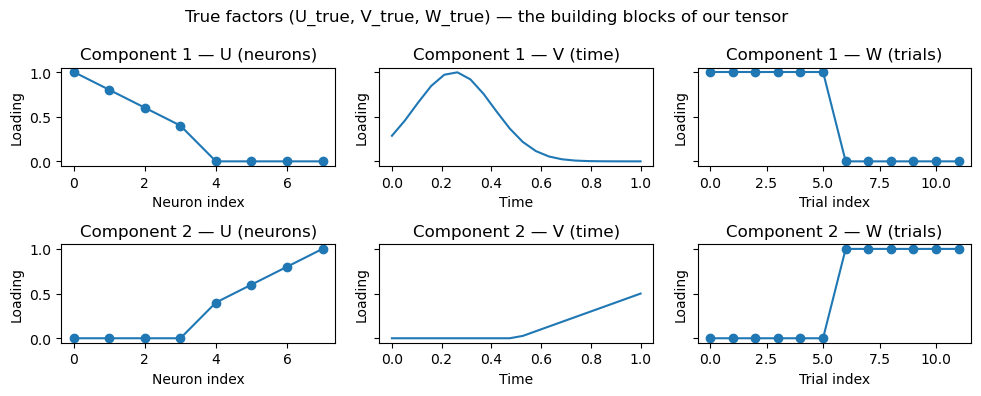

In [9]:
# Visualize the true factors we just built (same layout as the final True vs Recovered plot)
# These are exactly the "True" curves shown later when we compare to the fitted model.
fig, axes = plt.subplots(R, 3, figsize=(10, 4), sharey="row")
if R == 1:
    axes = axes.reshape(1, -1)
for r in range(R):
    ax = axes[r, 0]
    ax.plot(np.arange(n_neurons), U_true[:, r], "o-", color="C0")
    ax.set_ylabel("Loading")
    ax.set_xlabel("Neuron index")
    ax.set_title(f"Component {r+1} — U (neurons)")
    ax = axes[r, 1]
    ax.plot(t, V_true[:, r], "-", color="C0")
    ax.set_ylabel("Loading")
    ax.set_xlabel("Time")
    ax.set_title(f"Component {r+1} — V (time)")
    ax = axes[r, 2]
    ax.plot(trials, W_true[:, r], "o-", color="C0")
    ax.set_ylabel("Loading")
    ax.set_xlabel("Trial index")
    ax.set_title(f"Component {r+1} — W (trials)")
fig.suptitle("True factors (U_true, V_true, W_true) — the building blocks of our tensor")
plt.tight_layout()
plt.show()

In [3]:
# Build tensor as sum of R rank-1 tensors (outer products): X = sum_r u_r o v_r o w_r
# Using einsum: (i,r),(j,r),(k,r) -> ijk gives the r-th component as outer product
X = np.einsum("ir,jr,kr->ijk", U_true, V_true, W_true)

print("Tensor shape:", X.shape, "= (neurons, time, trials)")
print("Min: %.4f, Max: %.4f, Frobenius norm: %.4f" % (X.min(), X.max(), np.linalg.norm(X)))
# Sanity: rank-2 noiseless => we can exactly reconstruct from U_true, V_true, W_true
X_recon = np.einsum("ir,jr,kr->ijk", U_true, V_true, W_true)
assert np.allclose(X, X_recon), "Reconstruction from true factors should match X"
print("Check: reconstruction from true factors matches X (noiseless).")

Tensor shape: (8, 20, 12) = (neurons, time, trials)
Min: 0.0000, Max: 0.9965, Frobenius norm: 8.9727
Check: reconstruction from true factors matches X (noiseless).


## 3. The loss in code

What cp_als minimizes is the **Frobenius norm squared** of the residual. We compute it (and the normalized error we report in the pipeline) from the factor matrices using the same reconstruction formula as in `Batch_TCA_Pipeline.ipynb`.

In [4]:
def reconstruction_error(X, U, V, W):
    """Reconstruct from factors and return loss (Frobenius^2) and normalized error."""
    # X: (I, J, K), U:(I,R), V:(J,R), W:(K,R) -> Xhat same shape as X
    Xhat = np.einsum("ir,jr,kr->ijk", U, V, W)
    residual = X - Xhat
    loss_frobenius_sq = np.sum(residual ** 2)  # what cp_als minimizes
    norm_X = np.linalg.norm(X)
    normalized_err = np.linalg.norm(residual) / (norm_X + 1e-12)
    return loss_frobenius_sq, normalized_err, Xhat

# Using the *true* factors, loss should be 0 and normalized error 0
loss_sq, norm_err, _ = reconstruction_error(X, U_true, V_true, W_true)
print("Using TRUE factors:")
print("  Loss (Frobenius^2):", loss_sq)
print("  Normalized reconstruction error:", norm_err)
print("  (This is the quantity plotted in tt.plot_objective in the pipeline.)")

Using TRUE factors:
  Loss (Frobenius^2): 0.0
  Normalized reconstruction error: 0.0
  (This is the quantity plotted in tt.plot_objective in the pipeline.)


## 4. One ALS step by hand

**Alternating Least Squares (ALS):** We minimize $ \|\mathcal{X} - \hat{\mathcal{X}}\|_F^2 $ over U, V, W by alternating: fix two factor matrices and solve a **least-squares** problem for the third. Repeat until convergence.

- **Unfold** the tensor along one mode (e.g. mode 1 = neurons): $ X_{(1)} $ has shape *(n_neurons × n_time·n_trials)*.
- The CP model in that unfolding is $ X_{(1)} \approx U \cdot (W \odot V)^T $, where $ \odot $ is the Khatri–Rao product (columnwise Kronecker).
- With V and W fixed, the optimal U is given by the **normal equations**:  
  $ U = X_{(1)} \, (W \odot V) \, \big((V^T V) \ast (W^T W)\big)^{-1} $, where $ \ast $ is elementwise product.

Below we fix V and W (e.g. at the true values or a random init), compute one update for U, and check that the loss decreases.

In [5]:
def khatri_rao(A, B):
    """Khatri-Rao product (columnwise Kronecker). A (m x R), B (n x R) -> (m*n x R)."""
    r = A.shape[1]
    return np.column_stack([np.kron(A[:, cc], B[:, cc]) for cc in range(r)])

def unfold_mode1(T):
    """Unfold 3D tensor T (I,J,K) to mode-1 matrix shape (I, J*K)."""
    I, J, K = T.shape
    return T.reshape(I, -1)

# Fix V, W at true values; take a *wrong* initial U (e.g. random)
np.random.seed(42)
U_init = np.random.randn(n_neurons, R) * 0.5
loss_before, err_before, _ = reconstruction_error(X, U_init, V_true, W_true)

# One ALS step: update U given V_true, W_true
# U_new = X_(1) @ (W ⊙ V) @ inv((V'V) * (W'W))
X1 = unfold_mode1(X)
KR = khatri_rao(W_true, V_true)   # (n_trials * n_time, R)
M = (V_true.T @ V_true) * (W_true.T @ W_true)
U_one_step = X1 @ KR @ np.linalg.inv(M)

loss_after, err_after, _ = reconstruction_error(X, U_one_step, V_true, W_true)
print("Before one U-update: loss = %.6f, normalized err = %.6f" % (loss_before, err_before))
print("After one U-update (V,W fixed): loss = %.6f, normalized err = %.6f" % (loss_after, err_after))
print("Loss decreased:", loss_before > loss_after)

Before one U-update: loss = 107.978956, normalized err = 1.158095
After one U-update (V,W fixed): loss = 22.984090, normalized err = 0.534304
Loss decreased: True


## 5. Fit with tt.Ensemble(fit_method="cp_als")

We run the same procedure as in the pipeline: create an ensemble with `cp_als` and fit over a single rank (R=2). We take the first replicate and extract factor matrices U, V, W.

In [6]:
ensemble = tt.Ensemble(fit_method="cp_als")
ensemble.fit(X, ranks=[R], replicates=1, verbose=True)
# Get factors for rank R (first replicate). Tensortools may return (R, dim) or (dim, R); normalize to (dim, R)
(U_fit, V_fit, W_fit) = ensemble.factors(R)[0]
if U_fit.shape[0] == R:
    U_fit, V_fit, W_fit = U_fit.T, V_fit.T, W_fit.T
print("Fitted factor shapes: U", U_fit.shape, "V", V_fit.shape, "W", W_fit.shape)
loss_fit, err_fit, Xhat_fit = reconstruction_error(X, U_fit, V_fit, W_fit)
print("Reconstruction: loss = %.6f, normalized error = %.6f" % (loss_fit, err_fit))

Rank-2 models:  min obj, 0.00;  max obj, 0.00;  time to fit, 0.0s
Fitted factor shapes: U (8, 2) V (20, 2) W (12, 2)
Reconstruction: loss = 0.000000, normalized error = 0.000000


## 6. Sign and permutation indeterminacy

CP decomposition is **not unique** in two ways we must handle when comparing to the true factors:

1. **Sign:** Replacing $ (\mathbf{u}_r, \mathbf{v}_r, \mathbf{w}_r) $ by $ (-\mathbf{u}_r, -\mathbf{v}_r, \mathbf{w}_r) $ (or any two factors negated) gives the same outer product. So recovered components can be **flipped in sign**.
2. **Permutation:** The order of components is arbitrary. Component 1 in the fit might correspond to component 2 in the true model (and vice versa).
3. **Scale:** $ \mathbf{u}_r \circ \mathbf{v}_r \circ \mathbf{w}_r = (a\mathbf{u}_r) \circ (b\mathbf{v}_r) \circ (\mathbf{w}_r/(ab)) $, so the algorithm can return factors with very different magnitudes (e.g. tiny W, large U and V). For visualization we rescale each recovered factor to match the true factor's norm so the curves overlap.

**What to say when presenting:** "The algorithm recovers the same structure up to reordering, sign flips, and rescaling. We align and rescale for visualization so true vs recovered overlap."

**Presenter note:** Keep it brief: "We match each fitted component to the closest true component by correlation and flip signs so that the match is positive. Then we can plot true vs recovered on the same axes and show they overlap."

In [7]:
import itertools

# Ensure (dim, R) layout for fitted factors
if U_fit.shape[0] == R:
    U_fit, V_fit, W_fit = U_fit.T, V_fit.T, W_fit.T

# Helper to compute best error between True component r and Fitted component j
# We try all 4 valid sign triples that preserve the outer product sign.
def get_best_match_error(r_true, j_fit):
    # Returns (best_error, best_signs) for matching True component r with Fitted component j.
    # best_signs is a tuple (su, sv, sw).
    # Extract factors
    u_fit = U_fit[:, j_fit].astype(float)
    v_fit = V_fit[:, j_fit].astype(float)
    w_fit = W_fit[:, j_fit].astype(float)
    
    u_true = U_true[:, r_true]
    v_true = V_true[:, r_true]
    w_true = W_true[:, r_true]
    
    # Norms for scaling (we scale fit to match true norm for error calculation)
    # This handles scale indeterminacy before checking error
    nu_t = np.linalg.norm(u_true)
    nv_t = np.linalg.norm(v_true)
    nw_t = np.linalg.norm(w_true)
    
    nu_f = np.linalg.norm(u_fit)
    nv_f = np.linalg.norm(v_fit)
    nw_f = np.linalg.norm(w_fit)
    
    # Avoid div by zero
    if nu_f < 1e-12: u_fit_scaled = u_fit
    else: u_fit_scaled = u_fit / nu_f * nu_t
        
    if nv_f < 1e-12: v_fit_scaled = v_fit
    else: v_fit_scaled = v_fit / nv_f * nv_t
        
    if nw_f < 1e-12: w_fit_scaled = w_fit
    else: w_fit_scaled = w_fit / nw_f * nw_t
    
    # Valid sign triples for CP (even number of flips)
    VALID_TRIPLES = [(1, 1, 1), (-1, -1, 1), (-1, 1, -1), (1, -1, -1)]
    
    best_err = np.inf
    best_s = (1, 1, 1)
    
    for (su, sv, sw) in VALID_TRIPLES:
        # Apply signs
        u = u_fit_scaled * su
        v = v_fit_scaled * sv
        w = w_fit_scaled * sw
        
        # Total squared error across all 3 modes
        err = np.sum((u - u_true)**2) + np.sum((v - v_true)**2) + np.sum((w - w_true)**2)
        
        if err < best_err:
            best_err = err
            best_s = (su, sv, sw)
            
    # Prefer display where U aligns with true (positive correlation) so we don't show a globally flipped component
    u_best = u_fit_scaled * best_s[0]
    if np.dot(u_best, u_true) < 0:
        # Swap to the other valid triple that flips U: (1,1,1)<->(-1,-1,1), (-1,1,-1)<->(1,-1,-1)
        flip = {(1, 1, 1): (-1, -1, 1), (-1, -1, 1): (1, 1, 1), (-1, 1, -1): (1, -1, -1), (1, -1, -1): (-1, 1, -1)}
        best_s = flip[best_s]

    return best_err, best_s

# Find best permutation by minimizing total error across all components
# We check all permutations (R is small, e.g. 2)
R = U_true.shape[1]
permutations = list(itertools.permutations(range(R)))
best_perm_total_err = np.inf
best_perm = None
best_perm_signs = [] # List of (su, sv, sw) for each r in the best permutation

best_perm_alignment_score = -np.inf  # tie-breaker: prefer perm where aligned U matches true U

for perm in permutations:
    current_total_err = 0
    current_signs = []
    
    for r in range(R):
        j = perm[r]
        err, signs = get_best_match_error(r, j)
        current_total_err += err
        current_signs.append(signs)
    
    # Tie-breaker: when errors are equal (e.g. noiseless fit), prefer permutation where U factors align positively
    alignment_score = sum(np.dot(U_fit[:, perm[r]] * current_signs[r][0], U_true[:, r]) for r in range(R))
    if current_total_err < best_perm_total_err or (
        abs(current_total_err - best_perm_total_err) < 1e-12 and alignment_score > best_perm_alignment_score
    ):
        best_perm_total_err = current_total_err
        best_perm_alignment_score = alignment_score
        best_perm = perm
        best_perm_signs = current_signs

# Apply best permutation and signs
perm = np.array(best_perm)
sU = np.zeros(R)
sV = np.zeros(R)
sW = np.zeros(R)

for r in range(R):
    su, sv, sw = best_perm_signs[r]
    sU[r] = su
    sV[r] = sv
    sW[r] = sw

U_aligned = U_fit[:, perm] * sU
V_aligned = V_fit[:, perm] * sV
W_aligned = W_fit[:, perm] * sW

# Rescale each factor to match true scale for visualization
for r in range(R):
    for A_aligned, A_true_arr in [(U_aligned, U_true), (V_aligned, V_true), (W_aligned, W_true)]:
        nrm_true = np.linalg.norm(A_true_arr[:, r])
        nrm_aligned = np.linalg.norm(A_aligned[:, r])
        if nrm_aligned > 1e-12:
            A_aligned[:, r] *= nrm_true / nrm_aligned

print("Aligned and rescaled factors for visualization. Ready to plot true vs recovered.")


Aligned and rescaled factors for visualization. Ready to plot true vs recovered.


## 7. Visualize true vs recovered factors

Plot the true factors (U_true, V_true, W_true) and the aligned fitted factors (U_aligned, V_aligned, W_aligned) so we can see that the decomposition recovered the underlying dynamics. Use the same layout as in the pipeline: neurons (U), time (V), trials (W).

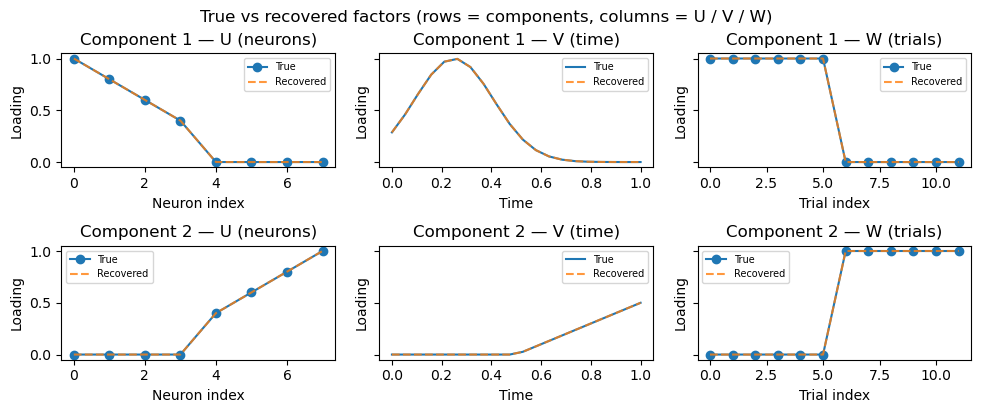

In [10]:
# Layout: rows = components (1, 2), columns = factors (U, V, W)
fig, axes = plt.subplots(R, 3, figsize=(10, 4), sharey="row")
if R == 1:
    axes = axes.reshape(1, -1)

for r in range(R):
    # Column 0: Neuron factor (U)
    ax = axes[r, 0]
    ax.plot(np.arange(n_neurons), U_true[:, r], "o-", label="True", color="C0")
    ax.plot(np.arange(n_neurons), U_aligned[:, r], "--", label="Recovered", color="C1", alpha=0.8)
    ax.set_ylabel("Loading")
    ax.set_xlabel("Neuron index")
    ax.set_title(f"Component {r+1} — U (neurons)")
    ax.legend(loc="best", fontsize=7)

    # Column 1: Time factor (V)
    ax = axes[r, 1]
    ax.plot(t, V_true[:, r], "-", label="True", color="C0")
    ax.plot(t, V_aligned[:, r], "--", label="Recovered", color="C1", alpha=0.8)
    ax.set_ylabel("Loading")
    ax.set_xlabel("Time")
    ax.set_title(f"Component {r+1} — V (time)")
    ax.legend(loc="best", fontsize=7)

    # Column 2: Trial factor (W)
    ax = axes[r, 2]
    ax.plot(trials, W_true[:, r], "o-", label="True", color="C0")
    ax.plot(trials, W_aligned[:, r], "--", label="Recovered", color="C1", alpha=0.8)
    ax.set_ylabel("Loading")
    ax.set_xlabel("Trial index")
    ax.set_title(f"Component {r+1} — W (trials)")
    ax.legend(loc="best", fontsize=7)

plt.tight_layout()
plt.suptitle("True vs recovered factors (rows = components, columns = U / V / W)", y=1.02)
plt.show()

**Presenter note:** Point out that the solid (true) and dashed (recovered) lines overlap: the noiseless rank-2 tensor is exactly recovered by CP. In real data we only get approximate recovery and need to choose rank (e.g. elbow on reconstruction error).

## How to export this notebook to slides

- **Reveal.js slides:**  
  `jupyter nbconvert simple_model.ipynb --to slides`  
  (creates `simple_model.slides.html`; open in a browser; press `s` for speaker notes if supported.)

- **Slide types in this notebook:** Section headers use `slide_type: slide`; content and code use `subslide`. Cells with `slide_type: notes` become speaker notes (not shown on the slide). To edit in Jupyter: **View → Cell Toolbar → Slideshow**, then set the dropdown for each cell.

- **Alternative:** Export to PDF via **File → Print Preview** or `nbconvert --to webpdf` for a handout; or copy markdown/code and figures into PowerPoint/Google Slides for full control over layout.